<a href="https://colab.research.google.com/github/adarshabhattacharjee/comp_neuro_NMA/blob/main/tutorials/W2D4_BiologicalNeuronModels/student/W2D4_Tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##The Leaky Integrate-and-Fire (LIF) Neuron Model



In [1]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()


feedback_prefix = "W2D3_T1"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 16.3 MB/s eta 0:00:00


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
# use NMA plot style
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")
my_layout = widgets.Layout()

In [4]:
# @title Plotting Functions

def plot_volt_trace(pars, v, sp):
  """
  Plot trajetory of membrane potential for a single neuron

  Expects:
  pars   : parameter dictionary
  v      : volt trajetory
  sp     : spike train

  Returns:
  figure of the membrane potential trajetory for a single neuron
  """

  V_th = pars['V_th']
  dt, range_t = pars['dt'], pars['range_t']
  if sp.size:
    sp_num = (sp / dt).astype(int) - 1
    v[sp_num] += 20  # draw nicer spikes

  plt.plot(pars['range_t'], v, 'b')
  plt.axhline(V_th, 0, 1, color='k', ls='--')
  plt.xlabel('Time (ms)')
  plt.ylabel('V (mV)')
  plt.legend(['Membrane\npotential', r'Threshold V$_{\mathrm{th}}$'],
             loc=[1.05, 0.75])
  plt.ylim([-80, -40])
  plt.show()


def plot_GWN(pars, I_GWN):
  """
  Args:
    pars  : parameter dictionary
    I_GWN : Gaussian white noise input

  Returns:
    figure of the gaussian white noise input
  """

  plt.figure(figsize=(12, 4))
  plt.subplot(121)
  plt.plot(pars['range_t'][::3], I_GWN[::3], 'b')
  plt.xlabel('Time (ms)')
  plt.ylabel(r'$I_{GWN}$ (pA)')
  plt.subplot(122)
  plot_volt_trace(pars, v, sp)
  plt.tight_layout()
  plt.show()


def my_hists(isi1, isi2, cv1, cv2, sigma1, sigma2):
  """
  Args:
    isi1 : vector with inter-spike intervals
    isi2 : vector with inter-spike intervals
    cv1  : coefficient of variation for isi1
    cv2  : coefficient of variation for isi2

  Returns:
    figure with two histograms, isi1, isi2

  """
  plt.figure(figsize=(11, 4))
  my_bins = np.linspace(10, 30, 20)
  plt.subplot(121)
  plt.hist(isi1, bins=my_bins, color='b', alpha=0.5)
  plt.xlabel('ISI (ms)')
  plt.ylabel('count')
  plt.title(r'$\sigma_{GWN}=$%.1f, CV$_{\mathrm{isi}}$=%.3f' % (sigma1, cv1))

  plt.subplot(122)
  plt.hist(isi2, bins=my_bins, color='b', alpha=0.5)
  plt.xlabel('ISI (ms)')
  plt.ylabel('count')
  plt.title(r'$\sigma_{GWN}=$%.1f, CV$_{\mathrm{isi}}$=%.3f' % (sigma2, cv2))
  plt.tight_layout()
  plt.show()

---
# Section 1: The Leaky Integrate-and-Fire (LIF) model



Now, it's your turn to implement one of the simplest mathematical model of a neuron: the leaky integrate-and-fire (LIF) model. The basic idea of LIF neuron was proposed in 1907 by Louis Édouard Lapicque, long before we understood the electrophysiology of a neuron (see a translation of [Lapicque's paper](https://pubmed.ncbi.nlm.nih.gov/17968583/) ). More details of the model can be found in the book [**Theoretical neuroscience**](http://www.gatsby.ucl.ac.uk/~dayan/book/) by Peter Dayan and Laurence F. Abbott.

The subthreshold membrane potential dynamics of a LIF neuron is described by

\begin{eqnarray}
C_m\frac{dV}{dt} = -g_L(V-E_L) + I,\quad (1)
\end{eqnarray}

where $C_m$ is the membrane capacitance, $V$ is the membrane potential, $g_L$ is the leak conductance ($g_L = 1/R$, the inverse of the leak resistance $R$ mentioned in previous tutorials), $E_L$ is the resting potential, and $I$ is the external input current.

Dividing both sides of the above equation by $g_L$ gives

\begin{align}
\tau_m\frac{dV}{dt} = -(V-E_L) + \frac{I}{g_L}\,,\quad (2)
\end{align}

where the $\tau_m$ is membrane time constant and is defined as $\tau_m=C_m/g_L$.

Note that dividing capacitance by conductance gives units of time!

Below, we will use Eqn.(2) to simulate LIF neuron dynamics.

If $I$ is sufficiently strong such that $V$ reaches a certain threshold value $V_{\rm th}$, $V$ is reset to a reset potential $V_{\rm reset}< V_{\rm th}$, and voltage is clamped to $V_{\rm reset}$ for $\tau_{\rm ref}$ ms, mimicking the refractoriness of the neuron during an action potential:

\begin{eqnarray}
\mathrm{if}\quad V(t_{\text{sp}})\geq V_{\rm th}&:& V(t)=V_{\rm reset} \text{  for } t\in(t_{\text{sp}}, t_{\text{sp}} + \tau_{\text{ref}}]
\end{eqnarray}
where $t_{\rm sp}$ is the spike time when $V(t)$ just exceeded $V_{\rm th}$.

(**Note:** in the lecture slides, $\theta$ corresponds to the threshold voltage $V_{th}$, and $\Delta$ corresponds to the refractory time $\tau_{\rm ref}$.)

</details>

Note that you have seen the LIF model before if you looked at the pre-reqs Python or Calculus days!

The LIF model captures the facts that a neuron:
- performs spatial and temporal integration of synaptic inputs
- generates a spike when the voltage reaches a certain threshold
- goes refractory during the action potential
- has a leaky membrane

The LIF model assumes that the spatial and temporal integration of inputs is linear. Also, membrane potential dynamics close to the spike threshold are much slower in LIF neurons than in real neurons.

## Python code to simulate the LIF neuron

We now write Python code to calculate our equation for the LIF neuron and simulate the LIF neuron dynamics. We will use the Euler method, which you saw in the linear systems case yesterday  to numerically integrate this equation:

\begin{equation}
\tau_m\frac{dV}{dt} = -(V-E_L) + \frac{I}{g_L}\,
\end{equation}

where $V$ is the membrane potential, $g_L$ is the leak conductance, $E_L$ is the resting potential, $I$ is the external input current, and $\tau_m$ is membrane time constant.

The cell below initializes a dictionary that stores parameters of the LIF neuron model and the simulation scheme. You can use `pars=default_pars(T=simulation_time, dt=time_step)` to get the parameters. Note that, `simulation_time` and `time_step` have the unit `ms`. In addition, you can add the value to a new parameter by `pars['New_param'] = value`.

In [5]:
# @markdown Execute this code to initialize the default parameters

def default_pars(**kwargs):
  pars = {}

  # typical neuron parameters#
  pars['V_th'] = -55.     # spike threshold [mV]
  pars['V_reset'] = -75.  # reset potential [mV]
  pars['tau_m'] = 10.     # membrane time constant [ms]
  pars['g_L'] = 10.       # leak conductance [nS]
  pars['V_init'] = -75.   # initial potential [mV]
  pars['E_L'] = -75.      # leak reversal potential [mV]
  pars['tref'] = 2.       # refractory time (ms)

  # simulation parameters #
  pars['T'] = 400.  # Total duration of simulation [ms]
  pars['dt'] = .1   # Simulation time step [ms]

  # external parameters if any #
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized time points [ms]

  return pars


pars = default_pars()
print(pars)

{'V_th': -55.0, 'V_reset': -75.0, 'tau_m': 10.0, 'g_L': 10.0, 'V_init': -75.0, 'E_L': -75.0, 'tref': 2.0, 'T': 400.0, 'dt': 0.1, 'range_t': array([0.000e+00, 1.000e-01, 2.000e-01, ..., 3.997e+02, 3.998e+02,
       3.999e+02])}


Complete the function below to simulate the LIF neuron when receiving external current inputs. You can use `v, sp = run_LIF(pars, Iinj)` to get the membrane potential (`v`) and spike train (`sp`) given the dictionary `pars` and input current `Iinj`.

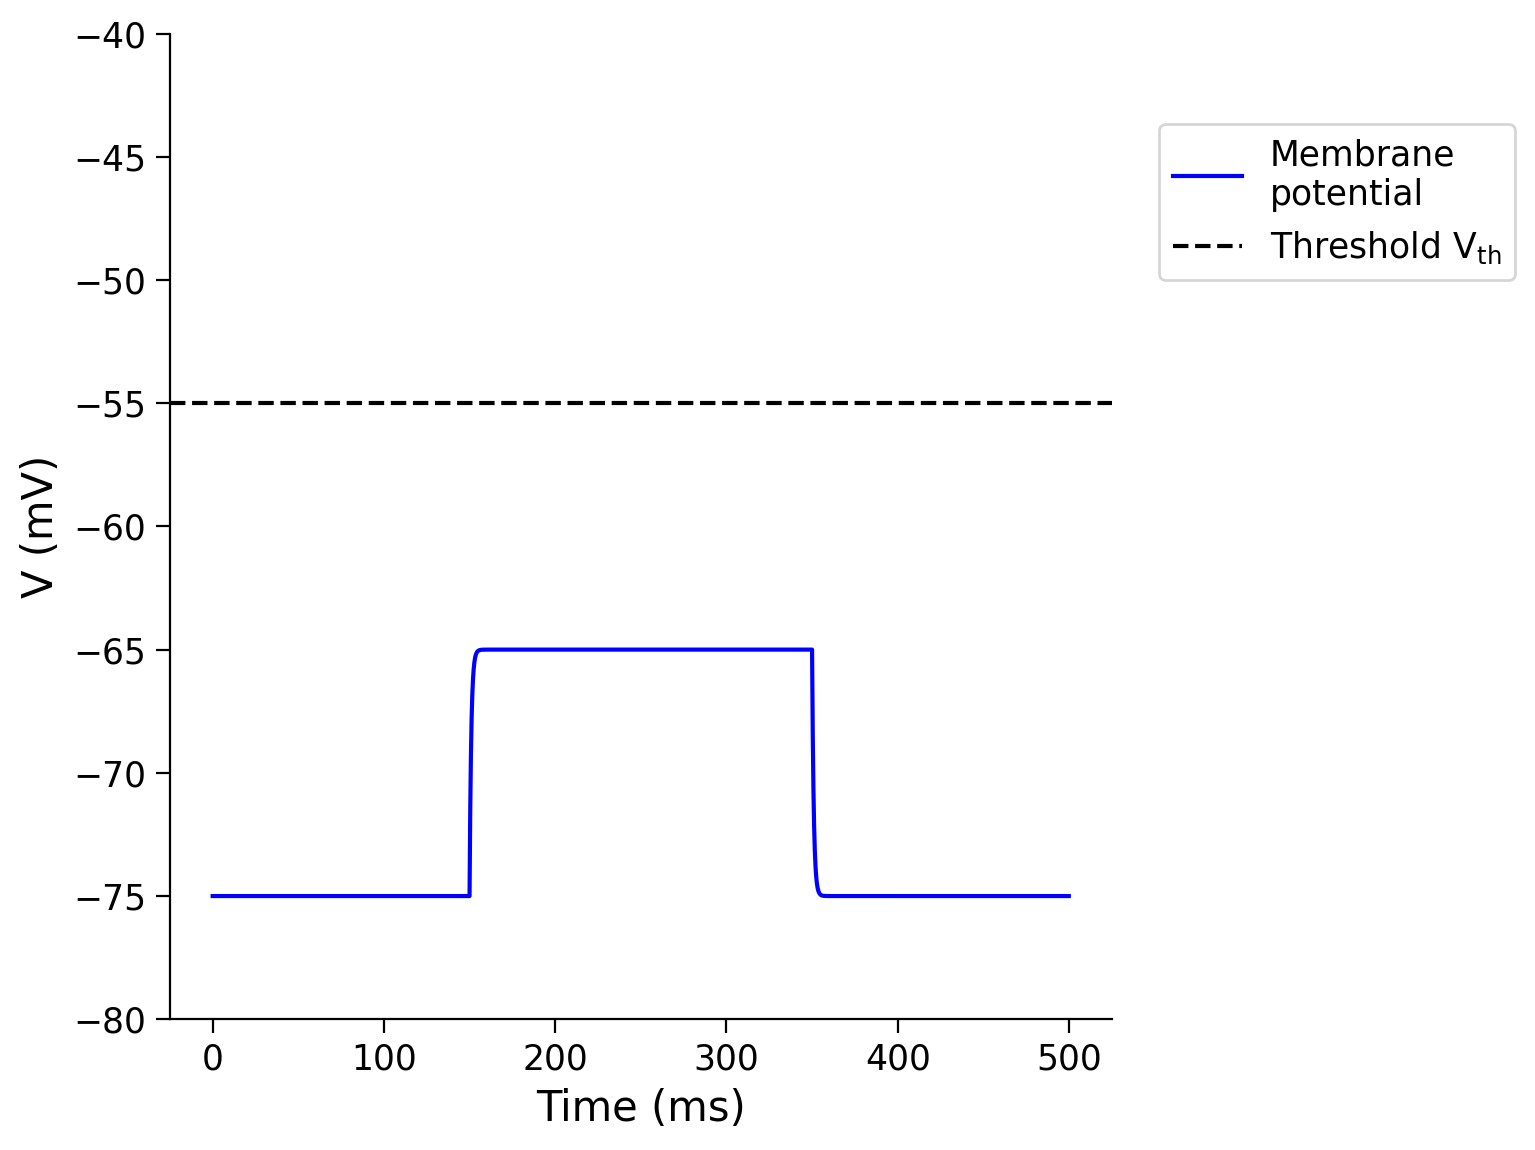

In [6]:
def run_LIF(pars, Iinj, stop=False):
  """
  Simulate the LIF dynamics with external input current

  Args:
    pars       : parameter dictionary
    Iinj       : input current [pA]. The injected current here can be a value
                 or an array
    stop       : boolean. If True, use a current pulse

  Returns:
    rec_v      : membrane potential
    rec_sp     : spike times
  """

  # Set parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, E_L = pars['V_init'], pars['E_L']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size
  tref = pars['tref']

  # Initialize voltage
  v = np.zeros(Lt)
  v[0] = V_init

  # Set current time course
  Iinj = Iinj * np.ones(Lt)

  # If current pulse, set beginning and end to 0
  if stop:
    Iinj[:int(len(Iinj) / 2) - 1000] = 0
    Iinj[int(len(Iinj) / 2) + 1000:] = 0

  # Loop over time
  rec_spikes = []  # record spike times
  tr = 0.  # the count for refractory duration

  for it in range(Lt - 1):

    if tr > 0:  # check if in refractory period
      v[it] = V_reset  # set voltage to reset
      tr = tr - 1 # reduce running counter of refractory period

    elif v[it] >= V_th:  # if voltage over threshold
      rec_spikes.append(it)  # record spike event
      v[it] = V_reset  # reset voltage
      tr = tref / dt  # set refractory time

    ########################################################################
    ## TODO for students: compute the membrane potential v, spike train sp #
    # Fill out function and remove
    #raise NotImplementedError('Student Exercise: calculate the dv/dt and the update step!')
    ########################################################################

    # Calculate the increment of the membrane potential
    dv = -(v[it] - E_L) + Iinj[it] / g_L

    # Update the membrane potential
    v[it + 1] = v[it] + dv * dt



  # Get spike times in ms
  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes


# Get parameters
pars = default_pars(T=500)

# Simulate LIF model
v, sp = run_LIF(pars, Iinj=100, stop=True)

# Visualize
plot_volt_trace(pars, v, sp)

###Response of an LIF model to different types of input currents


In the following section, we will learn how to inject direct current and white noise to study the response of an LIF neuron.

####Parameter exploration of DC input amplitude
Here's an interactive demo that shows how the LIF neuron behavior changes for DC input (constant current) with different amplitudes. We plot the membrane potential of an LIF neuron. You may notice that the neuron generates a spike. But this is just a cosmetic spike only for illustration purposes. In an LIF neuron, we only need to keep track of times when the neuron hits the threshold so the postsynaptic neurons can be informed of the spike.

How much DC is needed to reach the threshold (rheobase current)? How does the membrane time constant affect the frequency of the neuron?

In [7]:
# @markdown Make sure you execute this cell to enable the widget!
my_layout.width = '450px'
@widgets.interact(
    I_dc=widgets.FloatSlider(50., min=0., max=300., step=10.,
                             layout=my_layout),
    tau_m=widgets.FloatSlider(10., min=2., max=20., step=2.,
                              layout=my_layout)
)

def diff_DC(I_dc=200., tau_m=10.):
  pars = default_pars(T=100.)
  pars['tau_m'] = tau_m
  v, sp = run_LIF(pars, Iinj=I_dc)
  plot_volt_trace(pars, v, sp)
  plt.show()

interactive(children=(FloatSlider(value=50.0, description='I_dc', layout=Layout(width='450px'), max=300.0, ste…

## Section 2.2: Gaussian white noise (GWN) current


Given the noisy nature of neuronal activity _in vivo_, neurons usually receive complex, time-varying inputs.

To mimic this, we will now investigate the neuronal response when the LIF neuron receives Gaussian white noise $\xi(t)$ with mean 0 ($\mu = 0$) and some standard deviation $\sigma$.

Note that the GWN has zero mean, that is, it describes only the fluctuations of the input received by a neuron. We can thus modify our definition of GWN to have a nonzero mean value $\mu$ that equals the DC input, since this is the average input into the cell. The cell below defines the modified gaussian white noise currents with nonzero mean $\mu$.

### Interactive Demo 2.2: LIF neuron Explorer for noisy input


The mean of the Gaussian white noise (GWN) is the amplitude of DC. Indeed, when $\sigma = 0$, GWN is just a DC.

So the question arises how does $\sigma$ of the GWN affect the spiking behavior of the neuron. For instance we may want to know
1.  how does the minimum input (i.e., $\mu$) needed to make a neuron spike change with increase in $\sigma$
2.  how does the spike regularity change with increase in $\sigma$

To get an intuition about these questions you can use the following interactive demo that shows how the LIF neuron behavior changes for noisy input with different amplitudes (the mean $\mu$) and fluctuation sizes ($\sigma$). We use a helper function to generate this noisy input current: `my_GWN(pars, mu, sig, myseed=False)`.  Note that fixing the value of the random seed (e.g., `myseed=2020`) will allow you to obtain the same result every time you run this. We then use our `run_LIF` function to simulate the LIF model.

In [8]:
# @markdown Execute to enable helper function `my_GWN`

def my_GWN(pars, mu, sig, myseed=False):
  """
  Function that generates Gaussian white noise input

  Args:
    pars       : parameter dictionary
    mu         : noise baseline (mean)
    sig        : noise amplitute (standard deviation)
    myseed     : random seed. int or boolean
                 the same seed will give the same
                 random number sequence

  Returns:
    I          : Gaussian white noise input
  """

  # Retrieve simulation parameters
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # Set random seed
  if myseed:
      np.random.seed(seed=myseed)
  else:
      np.random.seed()

  # Generate GWN
  # we divide here by 1000 to convert units to sec.
  I_gwn = mu + sig * np.random.randn(Lt) / np.sqrt(dt / 1000.)

  return I_gwn

help(my_GWN)

Help on function my_GWN in module __main__:

my_GWN(pars, mu, sig, myseed=False)
    Function that generates Gaussian white noise input

    Args:
      pars       : parameter dictionary
      mu         : noise baseline (mean)
      sig        : noise amplitute (standard deviation)
      myseed     : random seed. int or boolean
                   the same seed will give the same
                   random number sequence

    Returns:
      I          : Gaussian white noise input



In [9]:
# @markdown Make sure you execute this cell to enable the widget!

my_layout.width = '450px'
@widgets.interact(
    mu_gwn=widgets.FloatSlider(200., min=100., max=300., step=5.,
                               layout=my_layout),
    sig_gwn=widgets.FloatSlider(2.5, min=0., max=5., step=.5,
                                layout=my_layout)
)


def diff_GWN_to_LIF(mu_gwn, sig_gwn):
  pars = default_pars(T=100.)
  I_GWN = my_GWN(pars, mu=mu_gwn, sig=sig_gwn)
  v, sp = run_LIF(pars, Iinj=I_GWN)
  plt.figure(figsize=(12, 4))
  plt.subplot(121)
  plt.plot(pars['range_t'][::3], I_GWN[::3], 'b')
  plt.xlabel('Time (ms)')
  plt.ylabel(r'$I_{GWN}$ (pA)')
  plt.subplot(122)
  plot_volt_trace(pars, v, sp)
  plt.tight_layout()
  plt.show()

interactive(children=(FloatSlider(value=200.0, description='mu_gwn', layout=Layout(width='450px'), max=300.0, …

1) If we have bigger current fluctuations (increased sigma), the minimum input needed
to make a neuron spike is smaller as the fluctuations can help push the voltage above
threshold.

2) The standard deviation (or size of current fluctuations) dictates the level of
irregularity of the spikes; the higher the sigma the more irregular the observed
spikes.


###Firing rate and spike time irregularity


When we plot the output firing rate as a function of GWN mean or DC value, it is called the input-output transfer function of the neuron (so simply F-I curve).

Spike regularity can be quantified as the **coefficient of variation (CV) of the interspike interval (ISI)**:

\begin{equation}
\text{CV}_{\text{ISI}} = \frac{std(\text{ISI})}{mean(\text{ISI})}
\end{equation}

A Poisson train is an example of high irregularity, in which $\textbf{CV}_{\textbf{ISI}} \textbf{= 1}$. And for a clocklike (regular) process we have $\textbf{CV}_{\textbf{ISI}} \textbf{= 0}$ because of **std(ISI)=0**.

## Interactive Demo 3A: F-I Explorer for different `sig_gwn`

How does the F-I curve of the LIF neuron change as we increase the $\sigma$ of the GWN? We can already expect that the F-I curve will be stochastic and the results will vary from one trial to another. But will there be any other change compared to the F-I curved measured using DC?

Here's an interactive demo that shows how the F-I curve of a LIF neuron changes for different levels of fluctuation $\sigma$.

In [18]:
# @markdown Make sure you execute this cell to enable the widget!

my_layout.width = '450px'
@widgets.interact(
    sig_gwn=widgets.FloatSlider(3.0, min=0., max=6., step=0.5,
                                layout=my_layout)
)


def diff_std_affect_fI(sig_gwn):
  pars = default_pars(T=1000.)
  I_mean = np.arange(100., 400., 10.)
  spk_count = np.zeros(len(I_mean))
  spk_count_dc = np.zeros(len(I_mean))

  for idx in range(len(I_mean)):
      I_GWN = my_GWN(pars, mu=I_mean[idx], sig=sig_gwn, myseed=2020)
      v, rec_spikes = run_LIF(pars, Iinj=I_GWN)
      v_dc, rec_sp_dc = run_LIF(pars, Iinj=I_mean[idx])
      spk_count[idx] = len(rec_spikes)
      spk_count_dc[idx] = len(rec_sp_dc)

  # Plot the F-I curve i.e. Output firing rate as a function of input mean.
  plt.figure()
  plt.plot(I_mean, spk_count, 'k',
           label=r'$\sigma_{\mathrm{GWN}}=%.2f$' % sig_gwn)
  plt.plot(I_mean, spk_count_dc, 'k--', alpha=0.5, lw=4, dashes=(2, 2),
           label='DC input')
  plt.ylabel('Spike count')
  plt.xlabel('Average injected current (pA)')
  plt.legend(loc='best')
  plt.show()

interactive(children=(FloatSlider(value=3.0, description='sig_gwn', layout=Layout(width='450px'), max=6.0, ste…

If we use a DC input, the F-I curve is deterministic, and we can
found its shape by solving the membrane equation of the neuron. If we have GWN,
as we increase the sigma, the F-I curve has a more linear shape, and the neuron
reaches its threshold using less average injected current.

###Compute $CV_{ISI}$ values

As shown above, the F-I curve becomes smoother while increasing the amplitude of the fluctuation ($\sigma$). In addition, the fluctuation can also change the irregularity of the spikes. Let's investigate the effect of $\mu=250$ with $\sigma=0.5$ vs $\sigma=3$.

Fill in the code below to compute ISI, then plot the histogram of the ISI and compute the $CV_{ISI}$. Note that, you can use `np.diff` to calculate ISI.

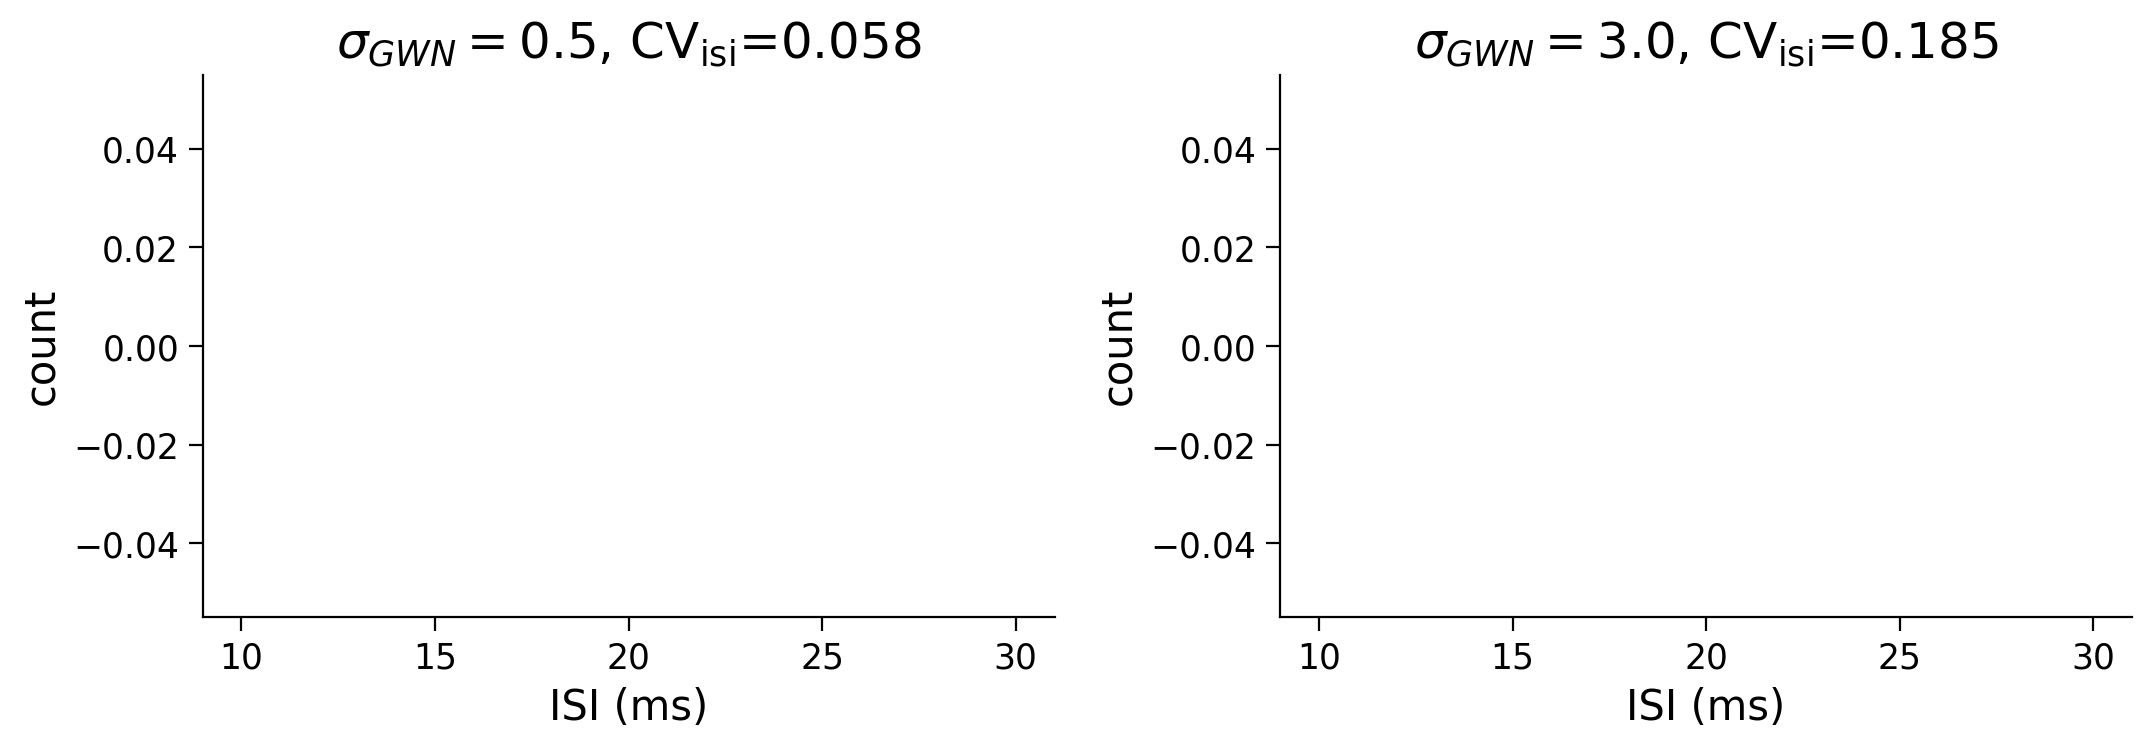

In [19]:
def isi_cv_LIF(spike_times):
  """
  Calculates the inter-spike intervals (isi) and
  the coefficient of variation (cv) for a given spike_train

  Args:
    spike_times : (n, ) vector with the spike times (ndarray)

  Returns:
    isi         : (n-1,) vector with the inter-spike intervals (ms)
    cv          : coefficient of variation of isi (float)

  """

  if len(spike_times) >= 2:
    # Compute isi
    isi = np.diff(spike_times)
    # Compute cv
    cv = isi.std()/isi.mean()
  else:
    isi = np.nan
    cv = np.nan

  return isi, cv


# Set parameters
pars = default_pars(T=1000.)
mu_gwn = 250
sig_gwn1 = 0.5
sig_gwn2 = 3.0

# Run LIF model for sigma = 0.5
I_GWN1 = my_GWN(pars, mu=mu_gwn, sig=sig_gwn1, myseed=2020)
_, sp1 = run_LIF(pars, Iinj=I_GWN1)

# Run LIF model for sigma = 3
I_GWN2 = my_GWN(pars, mu=mu_gwn, sig=sig_gwn2, myseed=2020)
_, sp2 = run_LIF(pars, Iinj=I_GWN2)

# Compute ISIs/CV
isi1, cv1 = isi_cv_LIF(sp1)
isi2, cv2 = isi_cv_LIF(sp2)

# Visualize
my_hists(isi1, isi2, cv1, cv2, sig_gwn1, sig_gwn2)

### Spike irregularity explorer for different `sig_gwn`

In the above illustration, we see that the CV of inter-spike-interval (ISI) distribution depends on $\sigma$ of GWN. What about the mean of GWN, should that also affect the CV$_{\rm ISI}$? If yes, how? Does the efficacy of $\sigma$ in increasing the CV$_{\rm ISI}$ depend on $\mu$?

In the following interactive demo, you will examine how different levels of fluctuation $\sigma$ affect the CVs for different average injected currents ($\mu$).

1. Does the standard deviation of the injected current affect the F-I curve in any qualitative manner?
2. Why does increasing the mean of GWN reduce the CV$_{\rm ISI}$?
3.  If you plot spike count (or rate) vs. CV$_{\rm ISI}$, should there be a relationship between the two? Try out yourself.

In [20]:
# @markdown Make sure you execute this cell to enable the widget!

my_layout.width = '450px'
@widgets.interact(
    sig_gwn=widgets.FloatSlider(0.0, min=0., max=10.,
                                step=0.5, layout=my_layout)
)


def diff_std_affect_fI(sig_gwn):
  pars = default_pars(T=1000.)
  I_mean = np.arange(100., 400., 20)
  spk_count = np.zeros(len(I_mean))
  cv_isi = np.empty(len(I_mean))

  for idx in range(len(I_mean)):
    I_GWN = my_GWN(pars, mu=I_mean[idx], sig=sig_gwn)
    v, rec_spikes = run_LIF(pars, Iinj=I_GWN)
    spk_count[idx] = len(rec_spikes)
    if len(rec_spikes) > 3:
      isi = np.diff(rec_spikes)
      cv_isi[idx] = np.std(isi) / np.mean(isi)

  # Plot the F-I curve i.e. Output firing rate as a function of input mean.
  plt.figure()
  plt.plot(I_mean[spk_count > 5], cv_isi[spk_count > 5], 'bo', alpha=0.5)
  plt.xlabel('Average injected current (pA)')
  plt.ylabel(r'Spike irregularity ($\mathrm{CV}_\mathrm{ISI}$)')
  plt.ylim(-0.1, 1.5)
  plt.grid(True)
  plt.show()

interactive(children=(FloatSlider(value=0.0, description='sig_gwn', layout=Layout(width='450px'), max=10.0, st…

1. Yes, it does. With DC input the F-I curve has a strong non-linearity but when
a neuron is driven with GWN, as we increase the $\sigma$ the non-linearity is
smoothened out. Essentially, in this case noise is acting to suppress the
non-linearities and render a neuron as a linear system.

2. When we increase the mean of the GWN, at some point
effective input mean is above the spike threshold and then the neuron operates
in the so called mean-driven regime -- as the input is so high all the neuron
is does is charge up to the spike threshold and reset. This essentially gives
almost regular spiking.

3. In an LIF, high firing rates are achieved for high GWN mean. Higher the mean,
higher the firing rate and lower the CV_ISI. So you will expect that as firing rate
increases, spike irregularity decreases. This is because of the spike threshold.
FOr a Poisson process there is no relationship between spike rate and spike
irregularity.